In [4]:
from google.colab import files
uploaded = files.upload()

Saving ab_data.csv to ab_data.csv


In [10]:
import numpy as np
import statsmodels.stats.api as sms

# 1. Definizione dei parametri pre-sperimentali (Pre-Test Sizing)
baseline_cr = 0.12       # Conversion rate storico (12%)
mde = 0.01               # Minimum Detectable Effect desiderato (+1% assoluto)
alpha = 0.05             # Tolleranza errore Tipo I (Falsi Positivi)
power = 0.80             # Potenza statistica 1 - Beta (Tolleranza Tipo II = 20%)

# Calcolo Effect Size per proporzioni binarie (Cohen's h)
target_cr = baseline_cr + mde
effect_size = sms.proportion_effectsize(baseline_cr, target_cr)

# Dimensionamento campionario minimo per ramo
required_n = sms.NormalIndPower().solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1.0
)
required_n = int(np.ceil(required_n))

print(f"Campione minimo richiesto per gruppo: {required_n:,} utenti")
print(f"Campione totale necessario (Control + Treatment): {required_n * 2:,} utenti")

Campione minimo richiesto per gruppo: 17,164 utenti
Campione totale necessario (Control + Treatment): 34,328 utenti


In [5]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.stats.api as sms

# 1. Caricamento del dataset
df = pd.read_csv("ab_data.csv")

print(f"Righe totali nel log: {len(df):,}")
print(f"Utenti unici: {df['user_id'].nunique():,}\n")

# 2. Controllo incrociato: Gruppo vs Landing Page
print("Distribuzione Gruppo vs Landing Page:")
display(pd.crosstab(df['group'], df['landing_page']))

Righe totali nel log: 294,478
Utenti unici: 290,584

Distribuzione Gruppo vs Landing Page:


landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145311,1965


In [6]:
# 1. Filtro righe coerenti e rimozione duplicati
aligned = (
    ((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))
)
df_clean = df[aligned].drop_duplicates(subset='user_id', keep='first').copy()

n_control = (df_clean['group'] == 'control').sum()
n_treatment = (df_clean['group'] == 'treatment').sum()
total_users = len(df_clean)

# 2. Test SRM (Split atteso: 50% Control / 50% Treatment)
observed = [n_control, n_treatment]
expected = [total_users / 2, total_users / 2]
chi2_stat, srm_p_value = stats.chisquare(f_obs=observed, f_exp=expected)

print(f"Utenti analizzati: {total_users:,}")
print(f"Control: {n_control:,} ({n_control/total_users:.2%})")
print(f"Treatment: {n_treatment:,} ({n_treatment/total_users:.2%})")
print(f"Chi2 Stat: {chi2_stat:.4f} | SRM p-value: {srm_p_value:.4f}")

if srm_p_value < 0.01:
    print("ALLERTA SRM: Distribuzione campionaria sbilanciata. Non procedere con l'inferenza.")
else:
    print("SRM PASSATO: Nessuna anomalia di allocazione del traffico.")

Utenti analizzati: 290,584
Control: 145,274 (49.99%)
Treatment: 145,310 (50.01%)
Chi2 Stat: 0.0045 | SRM p-value: 0.9468
SRM PASSATO: Nessuna anomalia di allocazione del traffico.


In [7]:
# Conteggio conversioni
conv_control = df_clean[df_clean['group'] == 'control']['converted'].sum()
conv_treatment = df_clean[df_clean['group'] == 'treatment']['converted'].sum()

cr_control = conv_control / n_control
cr_treatment = conv_treatment / n_treatment
diff = cr_treatment - cr_control

# Two-proportion Z-test a due code
z_stat, p_val = sm.stats.proportions_ztest(
    count=[conv_treatment, conv_control],
    nobs=[n_treatment, n_control],
    alternative='two-sided'
)

# Intervallo di confidenza al 95% per la differenza assoluta
se_diff = np.sqrt((cr_control * (1 - cr_control) / n_control) + (cr_treatment * (1 - cr_treatment) / n_treatment))
ci_lower = diff - 1.96 * se_diff
ci_upper = diff + 1.96 * se_diff

print(f"Conversion Rate Control:   {cr_control:.2%}")
print(f"Conversion Rate Treatment: {cr_treatment:.2%}")
print(f"Absolute Lift (Treatment - Control): {diff:+.4%}")
print(f"Relative Lift: {(diff / cr_control):+.2%}")
print(f"\nZ-statistic: {z_stat:.4f}")
print(f"p-value: {p_val:.4f}")
print(f"95% Confidence Interval for Difference: [{ci_lower:.4%}, {ci_upper:.4%}]")

Conversion Rate Control:   12.04%
Conversion Rate Treatment: 11.88%
Absolute Lift (Treatment - Control): -0.1578%
Relative Lift: -1.31%

Z-statistic: -1.3109
p-value: 0.1899
95% Confidence Interval for Difference: [-0.3938%, 0.0781%]


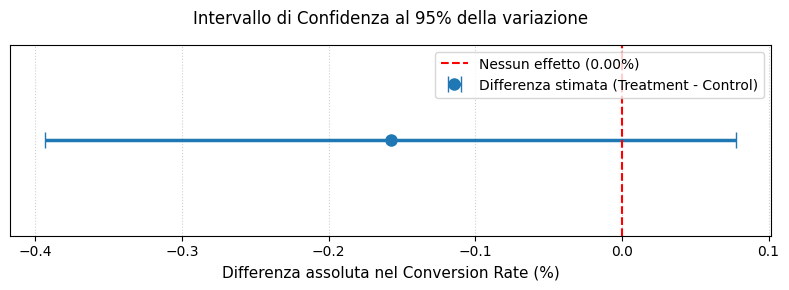

In [9]:
import matplotlib.pyplot as plt

# Grafico intervallo di confidenza dell'effetto del trattamento
fig, ax = plt.subplots(figsize=(8, 3), dpi=100)

ax.errorbar(
    x=diff * 100,
    y=0,
    xerr=1.96 * se_diff * 100,
    fmt='o',
    color='#1f77b4',
    ecolor='#1f77b4',
    elinewidth=2.5,
    capsize=6,
    markersize=8,
    label='Differenza stimata (Treatment - Control)'
)

# Linea di neutralità (differenza nulla = 0)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Nessun effetto (0.00%)')

ax.set_yticks([])
ax.set_xlabel('Differenza assoluta nel Conversion Rate (%)', fontsize=11)
ax.set_title('Intervallo di Confidenza al 95% della variazione', fontsize=12, pad=15)
ax.legend(loc='upper right', frameon=True)
ax.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## Executive Summary & Raccomandazione di Business

### Metriche Chiave
* **Control CR:** 12.04% (17.489 conversioni su 145.274 utenti)
* **Treatment CR:** 11.88% (17.264 conversioni su 145.310 utenti)
* **Lift Assoluto:** -0.16% (IC 95%: [-0.39%, +0.08%])
* **Lift Relativo:** -1.31%
* **Statistica del Test:** Z = -1.31, p-value = 0.1899 (alpha = 0.05)

### Sintesi Metodologica & Statistica
1. **Integrità del Campione (SRM Check):** Il test Chi-quadro di Goodness-of-Fit non ha evidenziato anomalie nell'allocazione del traffico (p-value = 0.9468), confermando l'assenza di Sample Ratio Mismatch.
2. **Significatività:** Con un p-value pari a 0.19 (superiore ad alpha = 0.05), non vi è evidenza sufficiente per rigettare l'ipotesi nulla ($H_0$).
3. **Intervallo di Confidenza:** L'intervallo al 95% include lo zero ([-0.39%, +0.08%]), con il baricentro orientato su valori negativi.

### Decisione Finale: DON'T SHIP (Rollback)
* **Azione:** Mantenere la versione corrente (`old_page`) ed evitare il rilascio della nuova landing page (`new_page`).
* **Valutazione del Rischio:** Il rollout comporterebbe un rischio asimmetrico a sfavore dell'azienda: potenziale calo del conversion rate fino a -0.39% a fronte di un upside massimo stimato ad appena +0.08%.
* **Next Steps:** Revisione qualitativa dell'esperienza utente (analisi funnel drop-off, scroll tracking e session replay) con il team UX/Product prima di formulare una nuova ipotesi di design.